# ___

# [ Machine Learning in Geosciences ]

**Department of Applied Geoinformatics and Carthography, Charles University** 

*Lukas Brodsky lukas.brodsky@natur.cuni.cz*

    
___


## End-to-End Machine Learning Project Workflow  Elements

This notebook demonstrates the elements of the ML workflow by Python code snippets.  The goal is to illustrate examples in the workflow. 

1. Task description 
2. Exploratory Data Analysis (EDA) 
3. Data preparation 
4. Select and train model 
5. Model fine-tuning 
6. Results interpretation


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

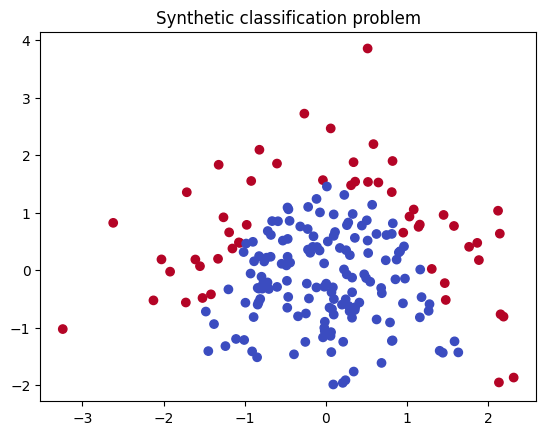

In [2]:
# Generated dataset 
np.random.seed(42)

X = np.random.randn(200, 2)
y = (X[:,0]**2 + X[:,1] > 1.5).astype(int)

plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Synthetic classification problem")
plt.show()

## 1.1. Task description

###  Problem Definition 

Objective: Demonstrate ML project workflow elemets as a systematic approach to model development & evaluation 

Data: Simulated

**Answers to checklist:**

    Target: 𝑦: binary class (0/1) → nonlinear function
    Inputs: 𝑋 two continuous features
    Task: classification
    Unit of observation: independent sample (point in feature space)
    Goal: prediction (not explanation)
    Assumption: boundary is nonlinear
    Good prediction: correct classification of unseen samples
    No spatial/temporal structure (IID assumed)


### Select the performance measures

F-1 score

In [3]:
# Data: 

print("X shape:", X.shape)
print("y distribution:", np.bincount(y))

X shape: (200, 2)
y distribution: [147  53]


---

## 2. Exploratory Data Analysis (EDA)

* Visualizing the data 
* Looking for correlations
* Experiment with attributes 


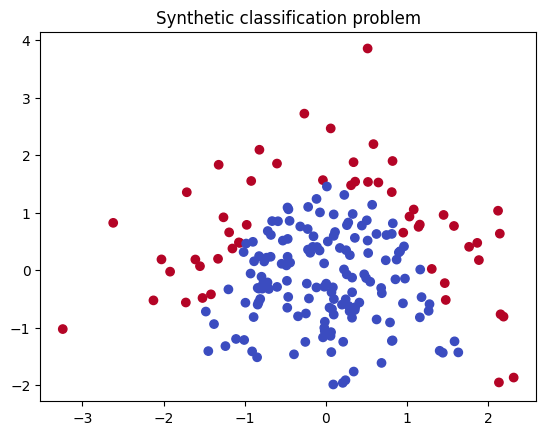

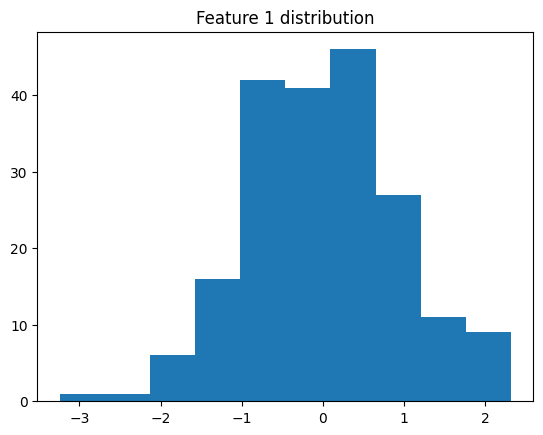

In [5]:
plt.hist(X[:,0])
plt.title("Feature 1 distribution")
plt.show()

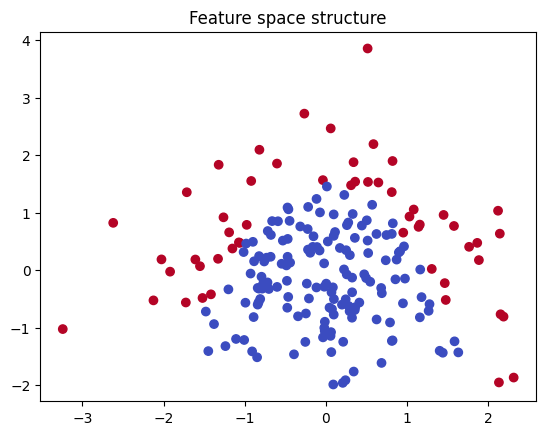

In [6]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Feature space structure")
plt.show()

**Answers to Checklist**

    * Features roughly Gaussian distributed
    * No missing values (synthetic data)
    * No extreme outliers
    * Dataset is reasonably balanced
    * Features weakly correlated
    * Clear nonlinear structure (regimes)
    * Data variability realistic (noise added)
    * No spatial/temporal structure

---

## 3. Data Preparation

Data preparation is a crucial step to ensure the quality and reliability of the model. This section focuses on feature engineering, which includes scaling, encoding categorical data, handling missing values, and splitting data correctly.

3.1. **Feature Engineering**
- Scaling: Normalization vs. Standardization
- Encoding categorical data: OneHotEncoder vs. Ordinal Encoder

3.2. **Handling Missing Data**
- Gap filling techniques (mean, interpolation, ML-based imputation)

3.3. **Splitting Data into Train/Test Sets**
- Random Sampling vs. Stratified Sampling (when to use each)
- Avoiding data leakage


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

In [ ]:
# pipeline 
pipeline = Pipeline([
    ("split", train_test_split())
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

**Answers to Checklist** 

    Data split before preprocessing ✔
    No leakage (no future info) ✔
    Scaling needed for logistic regression ✔
    No missing values
    No categorical variables
    No redundant features
    No class imbalance issue
    Pipeline ensures reproducibility ✔

## 4. Select & Train Model

**Suggestions**: 
- Always start with a simple model (baseline).
- Check linearity before selecting models.
- Take care of bias-variance tradeoff, adjust model complexity. 
- Potentially use learning & validation curves in case of iterative learning algorithm. 

#### Models and Assumptions

Logistic Regression: assumes linear boundary

    risk: underfitting

Decision Tree: assumes piecewise rules

    risk: overfitting

In [9]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

tree_model = DecisionTreeClassifier(max_depth=10)

log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

print("Logistic:", accuracy_score(y_test, log_model.predict(X_test)))
print("Tree:", accuracy_score(y_test, tree_model.predict(X_test)))

Logistic: 0.8166666666666667
Tree: 0.9333333333333333


**Answers to Checklist**

    Data is nonlinear → logistic may fail
    Tree can capture structure → better fit
    Tree sensitive to noise (high variance)
    No spatial structure considered
    Tree more interpretable
    Comparing multiple models ✔

## 5. Model Fine-Tuning

### Grid Search vs. Randomized Search

Grid Search exhaustively searches through a predefined hyperparameter grid. 

Randomized Search selects random combinations of hyperparameters to find the best model efficiently.

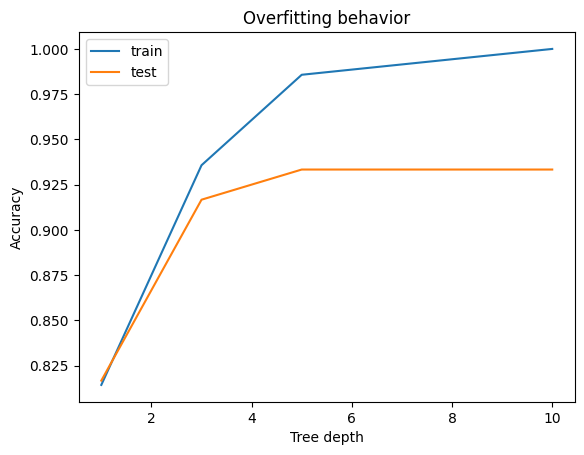

In [10]:
depths = [1, 3, 5, 10]
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train, y_train)
    
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_scores, label="train")
plt.plot(depths, test_scores, label="test")
plt.legend()
plt.xlabel("Tree depth")
plt.ylabel("Accuracy")
plt.title("Overfitting behavior")
plt.show()

In [ ]:
# TODO: GridSearch with cross-validation
pass 

In [ ]:
# Validation: compare train vs. test accuracy (F1-score) 
pass

**Answers to Checklist**

    Using simple train/test (can extend to CV)
    Test set is unseen ✔
    Hyperparameters (tree depth) tuned
    Risk: tuning on test → slight bias ⚠
    Metric: accuracy (OK for balanced data)
    Performance varies with depth
    Overfitting visible at large depth


---

# 6. Results Interpretation
 

[[44  2]
 [ 2 12]]


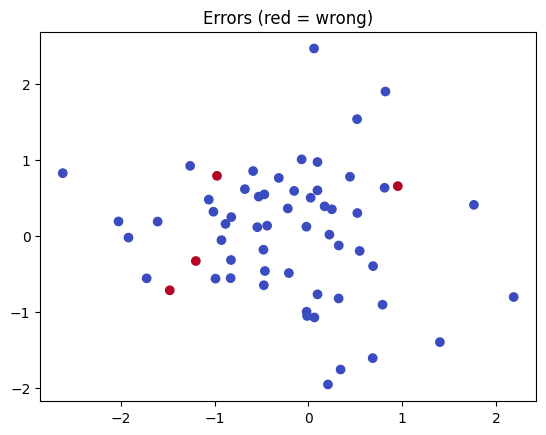

In [11]:
y_pred = tree_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))

errors = y_test != y_pred

plt.scatter(X_test[:,0], X_test[:,1], c=errors, cmap='coolwarm')
plt.title("Errors (red = wrong)")
plt.show()

**Answers to Checklist** 

    Tree with moderate depth generalizes best
    High depth → overfitting (train ↑, test ↓)
    Errors not fully random → structure exists
    Logistic regression underfits (too simple)
    Tree predictions align with nonlinear boundary
    Model is reasonable but may fail with noise increase
    Trust depends on data similarity

#### Final Reflection: 
1. Which model generalizes best and why?
2. Where does overfitting appear?
3. How does model capacity influence results?
4. What assumptions were correct or incorrect?
5. What would happen with noisier or spatial data?